# K means Segmentation

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
image = cv2.imread("../data/street.jpg")

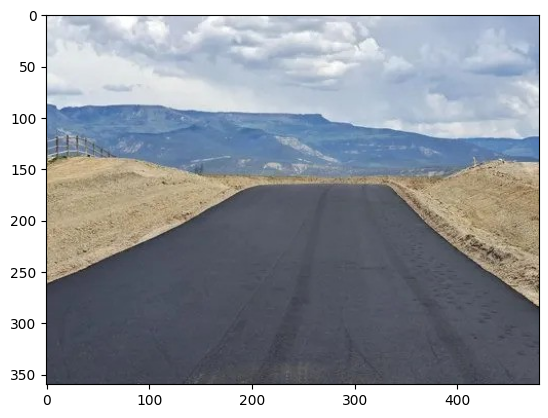

In [7]:
# BGR to RGB

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [8]:
image.shape


(360, 480, 3)

In [9]:
image = cv2.GaussianBlur(image, (3,3),0)

In [ ]:

pixel_values = image.reshape((-1,3))

In [ ]:

pixel_values = np.float32(pixel_values)
pixel_values

In [ ]:

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER , 100 , 0.75)

In [13]:
# retvals are the distances between the pixel and the centriods the smaller the better
# 10 attempts to initialize the random centriods
k=3
retvals , labels ,centers = cv2.kmeans(pixel_values, k , None , criteria , 10, cv2.KMEANS_RANDOM_CENTERS)

In [14]:
# converting the centeral pixel values of the cluters from float to int
# to be able to correctly represent the color as rgb is from 0 to 255
centers = np.uint8(centers)
print(centers) # color of each centriod


[[141 146 147]
 [192 203 216]
 [ 78  81  93]]


In [15]:
print(labels) # the cluster that each pixel belongs to

[[1]
 [1]
 [1]
 ...
 [2]
 [2]
 [2]]


In [ ]:

segmented_data = centers[labels.flatten()] # want to match the color of the pixel based on the cluster it belongs to
segmented_data

array([[192, 203, 216],
       [192, 203, 216],
       [192, 203, 216],
       ...,
       [ 78,  81,  93],
       [ 78,  81,  93],
       [ 78,  81,  93]], shape=(172800, 3), dtype=uint8)

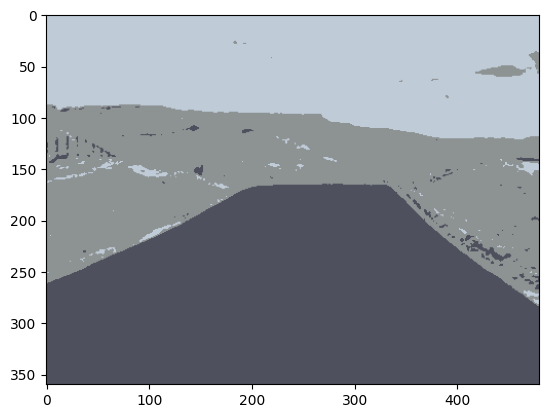

In [17]:
segmented_image = segmented_data.reshape(image.shape)
plt.imshow(segmented_image)